In [ ]:
!pip install pandas

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving Sample_Superstore.csv to Sample_Superstore.csv


In [ ]:
#1. Load a CSV file using pandas and display first 10 rows.
df = pd.read_csv("Sample_Superstore.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unnamed: 14
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.00,41.9136,NaN
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.00,219.5820,NaN
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.00,6.8714,NaN
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,NaN
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.20,2.5164,NaN
5,6,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,0.00,14.1694,NaN
6,7,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Art,Newell 322,7.28,4.0,0.00,1.9656,NaN
7,8,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6.0,0.20,90.7152,NaN
8,9,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3.0,0.20,5.7825,NaN
9,10,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9,5.0,0.00,34.4700,NaN


In [ ]:
#2-Print data types of each column and identify numerical vs categorical columns.

df.drop('Unnamed: 14', inplace=True, axis=1) #deleted an empty column
df.dtypes

#Numerical columns: Sales, Quantity, Discount, Profit,
#Categorical columns: Ship Mode, Segment, Category, Sub-category

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Segment,object
Category,object
Sub-Category,object
Product Name,object


In [ ]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce') #Sales columns was object type

In [ ]:
'''3. Handle missing values:
o Replace numerical NaNs with mean
o Replace categorical NaNs with mode'''

def replace_nan_values(df: pd.DataFrame) -> pd.DataFrame:
  df = df.copy()

  num_columns = ['Sales','Quantity', 'Discount', 'Profit']
  for col in num_columns:
    mean = df[col].mean()
    df[col] = df[col].fillna(mean)

  cat_columns = ['Ship Mode', 'Segment', 'Category', 'Sub-Category']
  for col in cat_columns:
    mode = df[col].mode()
    df[col] = df[col].fillna(mode[0])

  print("Replaced NaNs successfully")

  return df

replaced_df = replace_nan_values(df)



Replaced NaNs successfully


In [ ]:
#4. Filter rows where a chosen numeric column is above its median.

filtered_data = replaced_df[replaced_df['Sales']>replaced_df['Sales'].median()]

print(f"Median of Sales column: {replaced_df['Sales'].median()}")
filtered_data.head(10)

Median: 54.74


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
7,8,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6.0,0.20,90.7152
9,10,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5.0,0.00,34.4700
10,11,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9.0,0.20,85.3092
11,12,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4.0,0.20,68.3568
13,14,CA-2016-161389,12-05-2016,12-10-2016,Standard Class,IM-15070,Consumer,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.9760,3.0,0.20,132.5922
14,15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Home Office,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5.0,0.80,-123.8580
16,17,CA-2014-105893,11-11-2014,11/18/2014,Standard Class,PK-19075,Consumer,Office Supplies,Storage,"Stur-D-Stor Shelving, Vertical 5-Shelf: 72""H x...",665.8800,6.0,0.00,13.3176


In [ ]:
#5. Create a new column using apply() (e.g., categorise age group).

replaced_df['sales_category'] = df['Sales'].apply(
    lambda x: "High" if x > replaced_df['Sales'].median() else "Low"
)
replaced_df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,sales_category
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,High
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,High
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,Low
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,High
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,Low
5,6,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7.0,0.00,14.1694,Low
6,7,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Art,Newell 322,7.2800,4.0,0.00,1.9656,Low
7,8,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6.0,0.20,90.7152,High
8,9,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3.0,0.20,5.7825,Low
9,10,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Consumer,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5.0,0.00,34.4700,High


In [ ]:
#6. Compute summary statistics: mean, median, std of 3 numerical columns.

columns = ['Sales','Quantity', 'Discount']

for col in columns:
  print(f"Mean of column {col}: {replaced_df[col].mean()}")
  print(f"Median of column {col}: {replaced_df[col].median()}")
  print(f"Std of column {col}: {replaced_df[col].std()} \n")

Mean of column Sales: 229.64746596192387
Median of column Sales: 54.74
Std of column Sales: 622.7696962358187 

Mean of column Quantity: 3.9382450941129354
Median of column Quantity: 3.0
Std of column Quantity: 7.459249002264573 

Mean of column Discount: 0.15929643714971978
Median of column Discount: 0.2
Std of column Discount: 0.24665109188509365 



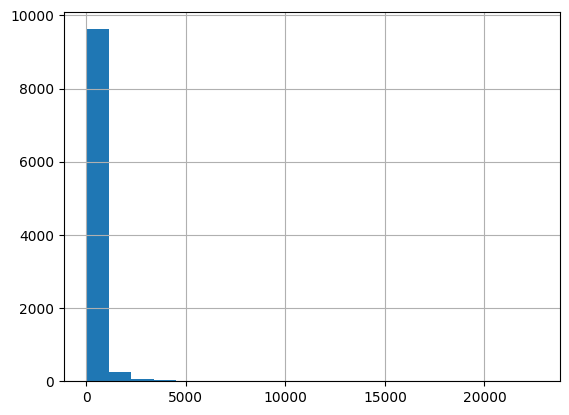

In [ ]:
#7. Plot a histogram for one column and a bar chart for a categorical column.
replaced_df['Sales'].hist(bins=20)

<Axes: xlabel='Category'>

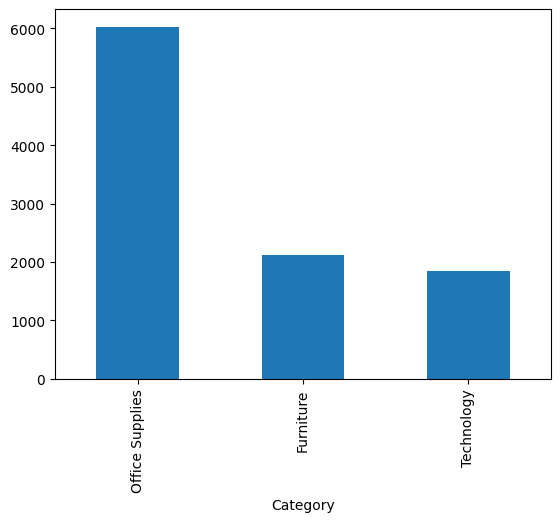

In [ ]:
replaced_df['Category'].value_counts().plot(kind='bar')

In [ ]:
#8. Save the transformed dataset back to CSV.

csv_path = "/content/Sample_Superstore_clean.csv"
replaced_df.to_csv(csv_path, index=False)